In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ee
import datetime
from tsconfig import START_DATE, END_DATE, extent_to_ee
import folium

In [2]:
project = 'afstuderen-481613'

try:
    ee.Initialize(project=project)
except:
    ee.Authenticate()
    ee.Initialize(project=project)

In [3]:
# Define region of interest
roi = ee.Geometry.Rectangle(extent_to_ee())

import folium
from tsconfig import extent_to_ee

# Get extent in EPSG:4326
xmin, ymin, xmax, ymax = extent_to_ee()

# Center of the extent
center_lat = (ymin + ymax) / 2
center_lon = (xmin + xmax) / 2

# Create map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="OpenStreetMap"
)

# Draw extent rectangle
folium.Rectangle(
    bounds=[[ymin, xmin], [ymax, xmax]],
    color="red",
    weight=2,
    fill=False
).add_to(m)

m.fit_bounds([[ymin, xmin], [ymax, xmax]])

# IMPORTANT: return the map (last line)
from IPython.display import display
display(m)


In [4]:
# Define time range
START_DATE = START_DATE
END_DATE = END_DATE

sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate(START_DATE, END_DATE).filterBounds(roi)

def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

sentinel2_ndvi = sentinel2.map(calculate_ndvi)

def reduce_region(image):
    stats = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=30
).get('NDVI')
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    return ee.Feature(None, properties={'date': date, 'NDVI': stats}) 

ndvi_ts = sentinel2_ndvi.map(reduce_region)

ndvi_values = ndvi_ts.aggregate_array('NDVI').getInfo()

dates = ndvi_ts.aggregate_array('date').getInfo()

dates = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in dates]

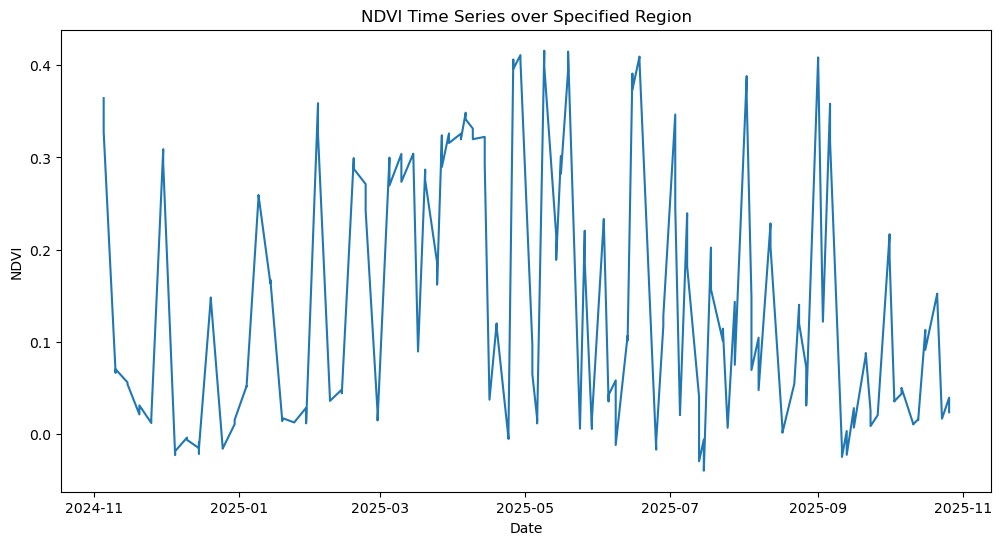

count                          185
mean     1 days 22:03:14.594594594
std      2 days 03:34:37.401908036
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:00
75%                5 days 00:00:00
max                7 days 00:00:00
dtype: object


In [5]:
plt.figure(figsize=(12,6))
plt.plot(dates, ndvi_values)
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('NDVI Time Series over Specified Region')
plt.show()     

deltas = np.diff(sorted(dates))
print(pd.Series(deltas).describe())